# Step 1: Importing Data Set

In [2]:
import pandas as pd

df=pd.read_csv('Heart_disease_cleveland_new.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


# Step 2: Understanding Data Set

In [5]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


# Step 3: EDA

### Finding Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

### Checking Target Column

In [10]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

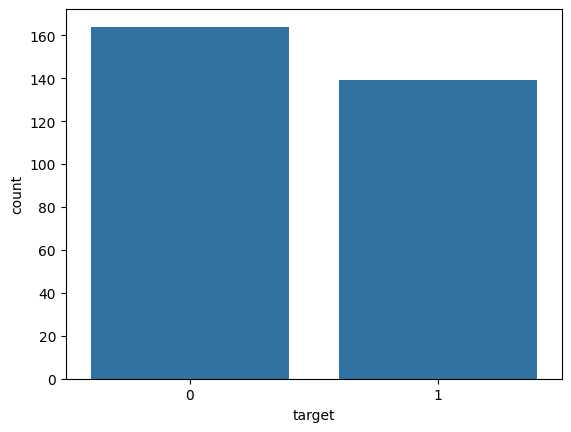

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.show()

### Correlation

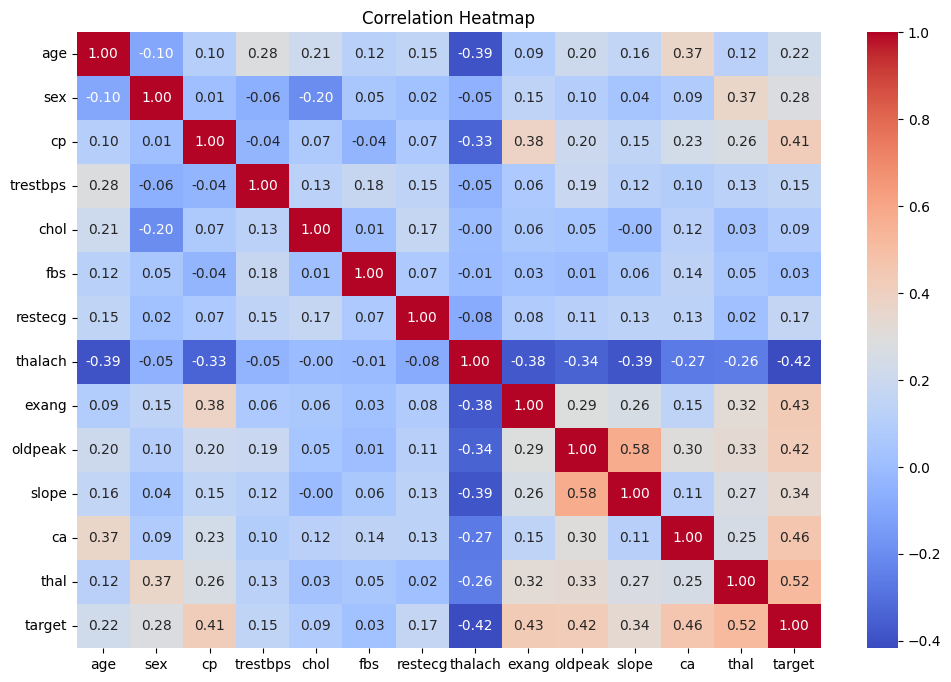

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
corr_matrix = df.corr()

# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Outlier Detection

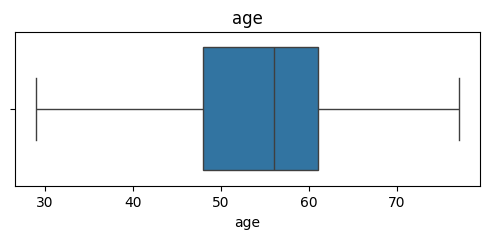

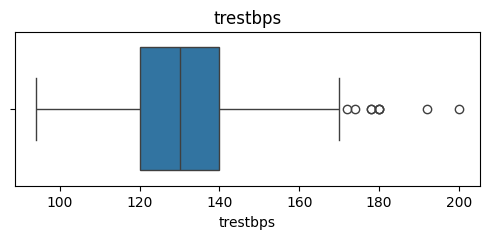

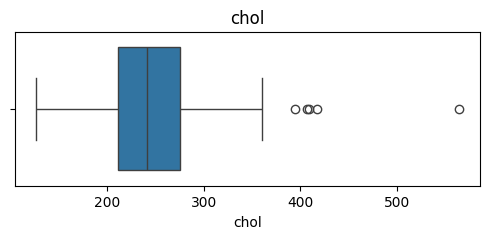

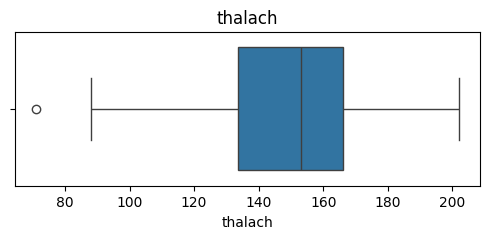

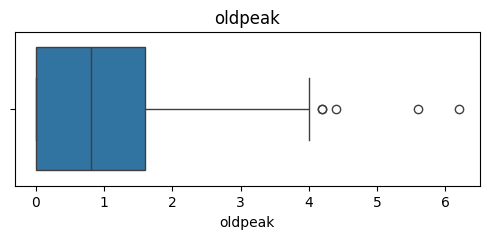

In [13]:
num_cols = ["age","trestbps","chol","thalach","oldpeak"]

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [15]:
df[num_cols].skew()

age        -0.209060
trestbps    0.706035
chol        1.135503
thalach    -0.537449
oldpeak     1.269720
dtype: float64

### Checking Distribution

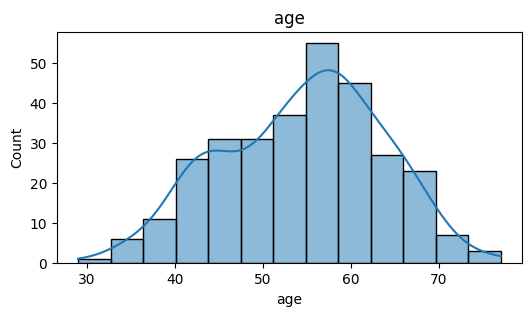

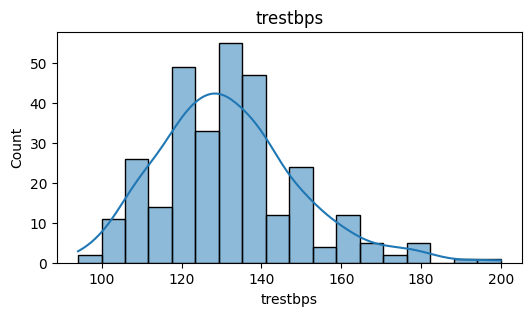

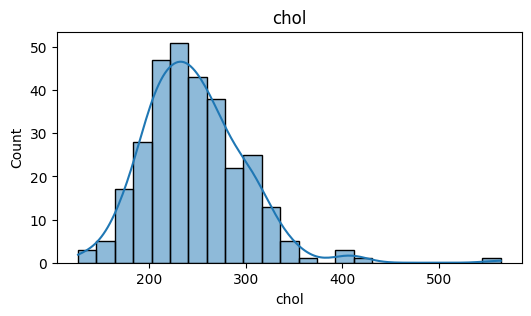

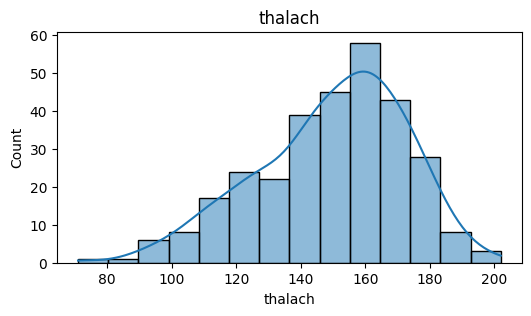

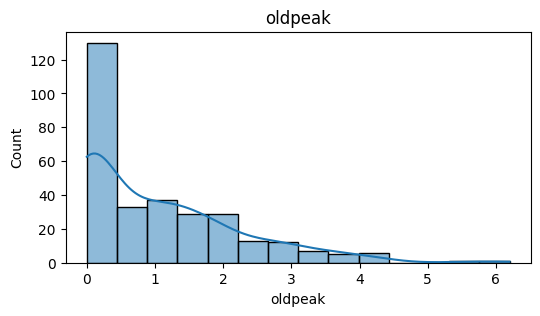

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,3))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)
    plt.show()

# Step 4: Train Test Split

In [17]:
# Features
X = df.drop("target", axis=1)

# Target
Y = df["target"]


from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("Y_train Shape:", Y_train.shape)
print("Y_test Shape :", Y_test.shape)

X_train Shape: (242, 13)
X_test Shape : (61, 13)
Y_train Shape: (242,)
Y_test Shape : (61,)


# Step 5: Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled.shape

(242, 13)

In [21]:
X_test_scaled.shape

(61, 13)

# Step 6: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

# Create Model
lr = LogisticRegression()

# Train Model
lr.fit(X_train_scaled, Y_train)

# Predictions
Y_pred_lr = lr.predict(X_test_scaled)

# First Few Predictions
print(Y_pred_lr[:10])

[1 1 1 1 1 1 1 1 0 1]


# Step 7: Evaluation Metrics for Logistic Regression

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Classification Metrics
lr_accuracy = accuracy_score(Y_test, Y_pred_lr)
lr_precision = precision_score(Y_test, Y_pred_lr)
lr_recall = recall_score(Y_test, Y_pred_lr)
lr_f1 = f1_score(Y_test, Y_pred_lr)

# ROC-AUC
Y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
lr_auc = roc_auc_score(Y_test, Y_prob_lr)

# Print Results
print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC :", lr_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred_lr))

Accuracy : 0.8852459016393442
Precision : 0.8787878787878788
Recall : 0.90625
F1 Score : 0.8923076923076924
ROC-AUC : 0.9213362068965516

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



# Step 8: Gaussian Naive Bayes

In [30]:
from sklearn.naive_bayes import GaussianNB

# Create Model
nb = GaussianNB()

# Train Model
nb.fit(X_train_scaled, Y_train)

# Predictions
Y_pred_nb = nb.predict(X_test_scaled)

print(Y_pred_nb[:10])

[1 1 1 0 1 1 1 1 0 0]


# Step 9: Evaluation Metrics for Gussian Naiva Bays

In [31]:
nb_accuracy = accuracy_score(Y_test, Y_pred_nb)
nb_precision = precision_score(Y_test, Y_pred_nb)
nb_recall = recall_score(Y_test, Y_pred_nb)
nb_f1 = f1_score(Y_test, Y_pred_nb)

Y_prob_nb = nb.predict_proba(X_test_scaled)[:,1]
nb_auc = roc_auc_score(Y_test, Y_prob_nb)

print("Accuracy :", nb_accuracy)
print("Precision :", nb_precision)
print("Recall :", nb_recall)
print("F1 Score :", nb_f1)
print("ROC-AUC :", nb_auc)

print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred_nb))

Accuracy : 0.8524590163934426
Precision : 0.896551724137931
Recall : 0.8125
F1 Score : 0.8524590163934426
ROC-AUC : 0.9170258620689654

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



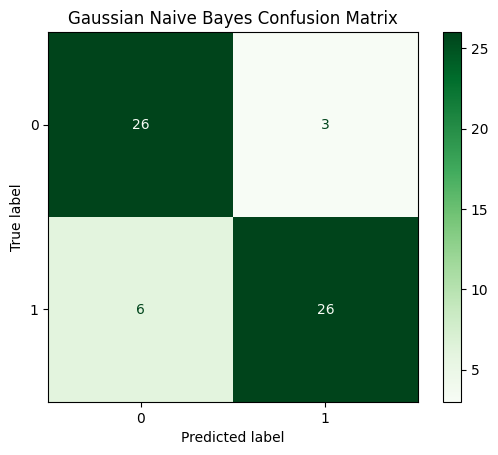

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    Y_pred_nb,
    cmap="Greens"
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.show()

# Step 10: Final Comparison Table

In [34]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Gaussian Naive Bayes"],
    "Accuracy": [lr_accuracy, nb_accuracy],
    "Precision": [lr_precision, nb_precision],
    "Recall": [lr_recall, nb_recall],
    "F1 Score": [lr_f1, nb_f1],
    "ROC-AUC": [lr_auc, nb_auc]
})

comparison_df = comparison_df.round(3)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885,0.879,0.906,0.892,0.921
1,Gaussian Naive Bayes,0.852,0.897,0.812,0.852,0.917
